# import

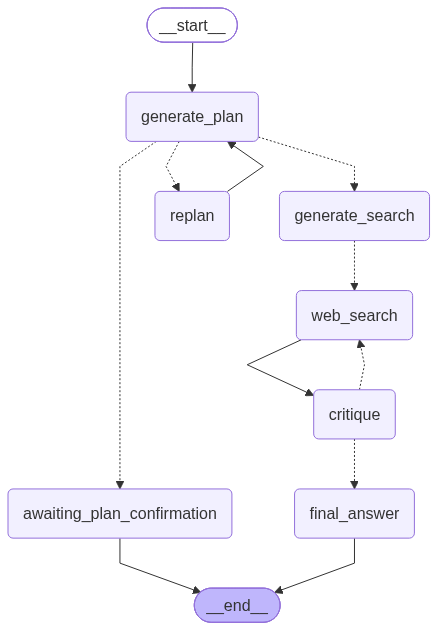

In [3]:
from IPython.core.display import Image
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langgraph.constants import START, END

from src.agent.graph import (
    GENERATE_SEARCH_NODE,
    WEB_SEARCH_NODE,
    CRITIQUE_NODE,
    FINAL_ANSWER_NODE)

from src.agent.graph import (
    generate_plan,
    evaluate_plan,

    generate_query,
    web_search,

    critique,
    final_answer,

    send_to_web_search,
    route_evaluate,

    graph
)
from src.agent.configuration import Configuration
from src.agent.state import OverallState
from langgraph.graph import StateGraph
from rich import print as rprint
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

# Plan

## Generate Plan

In [5]:
state: OverallState = OverallState(
    messages=[HumanMessage(content='现在企业级的 AI Agent 落地方案深度调研')]
)
config: RunnableConfig = RunnableConfig(configurable={
    "number_of_initial_queries":3,
    "query_generator_model":"MiniMax-M3"
})
plan_result = generate_plan(state,config)


2026-09-03 12:47:01.264 | INFO     | src.agent.graph:generate_plan:57 - 正在生成计划...
2026-09-03 12:47:26.248 | INFO     | src.agent.graph:generate_plan:70 - {'messages': [HumanMessage(content='现在企业级的 AI Agent 落地方案深度调研', additional_kwargs={}, response_metadata={})]}
2026-09-03 12:47:26.250 | INFO     | src.agent.graph:generate_plan:71 - # 需求清晰度进度条: 25%

## 核心需求理解：
1. **核心分析对象 (Subjects)**: 用户希望调研"企业级 AI Agent"的"落地方案"，即 AI Agent 如何在企业场景中实际部署和应用。当前需求的对象范围过于宽泛，需要进一步明确具体分析维度。
2. **对手策略维度 (Opponent's Strategy)**: 当前需求未涉及特定对手/竞争方分析，但可能隐含厂商对比或技术路线竞争分析。
3. **风险研判维度 (Risk Assessment)**: 落地方案天然涉及多维风险（技术成熟度、ROI、数据安全、组织变革等），需进一步确认。
4. **信息时空边界 (Scope & Boundaries)**:
   - 时间范围: 未指定（建议默认最近1-2年，因 AI Agent 领域迭代极快）
   - 媒体范围: 未指定（可涵盖行业报告、厂商白皮书、技术媒体、投融资数据库等）
   - 具体信源: 未指定
5. **成果呈现形式 (Output Format)**: 未指定报告格式与深度。

---

## 待确认问题（请逐项选择或补充）：

### 🔹 一、分析对象细化（核心维度）
"企业级 AI Agent 落地方案"涵盖面很广，请明确您最关心的分析维度（可多选）：
- **A. 技术架构层**：Agent 框架选型（如 LangGraph、AutoGen、CrewAI、自研框架）、RAG、知识库、工具调用、多 Agent 协同等
- **B. 主流厂商与产品对比**

In [7]:
plan_result

{'messages': [AIMessage(content='# 需求清晰度进度条: 25%\n\n## 核心需求理解：\n1. **核心分析对象 (Subjects)**: 用户希望调研"企业级 AI Agent"的"落地方案"，即 AI Agent 如何在企业场景中实际部署和应用。当前需求的对象范围过于宽泛，需要进一步明确具体分析维度。\n2. **对手策略维度 (Opponent\'s Strategy)**: 当前需求未涉及特定对手/竞争方分析，但可能隐含厂商对比或技术路线竞争分析。\n3. **风险研判维度 (Risk Assessment)**: 落地方案天然涉及多维风险（技术成熟度、ROI、数据安全、组织变革等），需进一步确认。\n4. **信息时空边界 (Scope & Boundaries)**:\n   - 时间范围: 未指定（建议默认最近1-2年，因 AI Agent 领域迭代极快）\n   - 媒体范围: 未指定（可涵盖行业报告、厂商白皮书、技术媒体、投融资数据库等）\n   - 具体信源: 未指定\n5. **成果呈现形式 (Output Format)**: 未指定报告格式与深度。\n\n---\n\n## 待确认问题（请逐项选择或补充）：\n\n### 🔹 一、分析对象细化（核心维度）\n"企业级 AI Agent 落地方案"涵盖面很广，请明确您最关心的分析维度（可多选）：\n- **A. 技术架构层**：Agent 框架选型（如 LangGraph、AutoGen、CrewAI、自研框架）、RAG、知识库、工具调用、多 Agent 协同等\n- **B. 主流厂商与产品对比**：国内外头部厂商方案（如阿里云、字节、百度、智谱、Salesforce Agentforce、Microsoft Copilot Studio、AWS Bedrock Agents 等）\n- **C. 典型应用场景与案例**：金融、客服、运维、研发、销售、营销、政务等行业的落地实例\n- **D. 商业化与 ROI 分析**：定价模式、部署成本、效率提升量化数据\n- **E. 投融资与市场格局**：2024-2026 年 AI Agent 赛道的融资趋势、估值逻辑\n- **F. 其他（请说明）_______**\n\n### 🔹 二、地理与行业范围\n

## evaluate_plan

In [8]:

evaluate_result = evaluate_plan(state=plan_result,config=config)
evaluate_result

2026-09-03 12:57:03.834 | INFO     | src.agent.graph:evaluate_plan:97 - 等待用户确认...


'awaiting_plan_confirmation'

# Query

## Generate Search 生成查询 的主题
 - 提示词：LLM 拆分生成 {{num}} 个相关的主题
 - json 解析
 - 使用 JsonAgent

In [ ]:
state: OverallState = OverallState(
    messages=[HumanMessage(content='现在企业级的 AI Agent 落地方案深度调研')]
)
config: RunnableConfig = RunnableConfig(configurable={
    "number_of_initial_queries":3,
    "query_generator_model":"MiniMax-M3"
})

searches = generate_query(state=state,config=config)
rprint(searches)

# Send to Web Search : 按照主题数，生成分发到 web search 的任务

In [ ]:

sends = send_to_web_search(searches)
rprint(sends)

# Web Search 实际调用 Web Search MCP 并解析

- 将以上生成的 sub topic 调用 mcp 生成 {{count}} 个 主题 和内容，并携带对应的 **title**, **url** ,**content**
- 给 url 生成 **short url 短链**
- **内容整合&总结**：调用 LLM 生成

In [ ]:
# 结果中 增加了 web_search_result，sources_gathered
web_searches:list[OverallState] = []
for send in sends:
    result = web_search(send.arg,config=config)
    web_searches.append(result)

rprint(web_searches[-1])

# critique 评估

In [ ]:
from agent.state import ReflectionState

rprint(len(web_searches))
# rprint(web_searches)
#
sources_gathered = []
search_query = []
web_search_result = []
for s in web_searches:
    sources_gathered = sources_gathered + s['sources_gathered']
    search_query = search_query + s['search_query']
    web_search_result = web_search_result + s['web_search_result']

initial_search_query_count = 2

web_search_result_state:OverallState = OverallState(
    messages=state.get('messages'),
    sources_gathered=sources_gathered,
    search_query=search_query,
    web_search_result=web_search_result,
    initial_search_query_count=initial_search_query_count

)
web_search_result_state

In [ ]:

# rprint(web_search_result_state)
# web_search_result
critique_result:ReflectionState = critique(state=web_search_result_state,config=config)
rprint(critique_result)

# Route Evaluate

In [ ]:

evaluate_state:OverallState = route_evaluate(state=critique_result,config=config)
rprint(evaluate_state)

## Re-Send to Web Search

In [ ]:
# 结果中 增加了 web_search_result，sources_gathered
web_searches_2:list[OverallState] = []
for send in evaluate_state:
    result = web_search(send.arg,config=config)
    web_searches_2.append(result)

rprint(web_searches_2[-1])

# Re-Critique 二次评估

In [ ]:
from agent.state import ReflectionState

web_searches_tmp = web_searches + web_searches_2
rprint(len(web_searches_tmp))
# rprint(web_searches)
#
sources_gathered_2 = []
search_query_2 = []
web_search_result_2 = []
for s in web_searches_tmp:
    sources_gathered_2 = sources_gathered_2 + s['sources_gathered']
    search_query_2 = search_query_2 + s['search_query']
    web_search_result_2 = web_search_result_2 + s['web_search_result']


web_search_result_state_2:OverallState = OverallState(
    messages=state.get('messages'),
    sources_gathered=sources_gathered_2,
    search_query=search_query_2,
    web_search_result=web_search_result_2,
    initial_search_query_count=initial_search_query_count

)
web_search_result_state_2

In [ ]:

# rprint(web_search_result_state)
# web_search_result
critique_result_2:ReflectionState = critique(state=web_search_result_state_2,config=config)
rprint(critique_result_2)

# Answer

In [ ]:
answer_state = OverallState(
    messages=web_search_result_state_2.get('messages'),
    sources_gathered=web_search_result_state_2.get("sources_gathered"),
    web_search_result=web_search_result_state_2.get("web_search_result"),
    initial_search_query_count=initial_search_query_count
)
# answer_state

In [ ]:
answer = final_answer(answer_state,config)
answer